In [26]:
# The first step is to load some standard python packages (numpy, pandas, scipy and matplotlib.pyplot).
import matplotlib.pyplot as plt
# %matplotlib ipympl
import pandas as pd
import numpy as np
import scipy.stats as stats
from matplotlib.dates import DateFormatter
from datetime import timedelta



In [27]:
def plot_pdef_year(df, years):
    """
    Plot the rainfall deficit for a specific year from a larger dataframe. Also show the climatology of rainfall deficit
    """
    # CLIMATOLOGY
        # set up a figure with a given width, height size
    f = plt.figure(figsize=(10, 8))
    # add one subplot to the figure
    ax = f.add_subplot(111)
    # group all the years of data into a regular day of year climatology. This puts all values at the same day of the year into groups
    df_clim = df.groupby(df.index.dayofyear)
    # compute the upper bound of the climatology by taking the 97.5 percentile of each group. result is a day-of-year time series
    upper = df_clim.quantile(0.975)
    # same but for the lower bound
    lower = df_clim.quantile(0.025)
    # Also compute upper and lower bounds for the 25 and 75 percentiles
    upper_2 = df_clim.quantile(0.75)
    lower_2 = df_clim.quantile(0.25)
    # and finally, also compute the median climatology
    median = df_clim.median()
    # prepare a date range for the climatology values, equal to the length of climatology
    clim_dates = pd.date_range(start=df['1979'].index.min(), end=df['1979'].index.max(),freq='D')
    # plot the climatology bounds with different shadings
    ax.fill_between(clim_dates, lower[0:len(clim_dates)], upper[0:len(clim_dates)], color='grey', alpha=0.3, label='95% interval')
    ax.fill_between(clim_dates, lower_2[0:len(clim_dates)], upper_2[0:len(clim_dates)], color='grey', alpha=0.5, label='50% interval')
    # also plot the median
    ax.plot(clim_dates, median[0:len(clim_dates)], label='median', color='k')
    
    # INDIVIDUAL YEARS
    for y in years:
        # retrieve the values of the time series, belonging to 'y'
        df_oneyear = df[df.index.year==y]
        # finally, plot the actual year of interest over the climatology shadings
        ax.plot(clim_dates, df_oneyear, label='{:d}'.format(y))
    
    # finalize plot
    ax.set_xlabel('Time')
    ax.set_ylabel('Deficit (mm)')
    ax.grid()
    ax.legend()
    date_form = DateFormatter("%b")
    ax.xaxis.set_major_formatter(date_form)
    return ax

In [28]:
filename = 'mswep/Black_Volta.csv'

In [29]:
station = pd.read_csv(filename, index_col=['time'], parse_dates=['time']) 
#Look what is in the file:
station.head(15)

,precipitation
time,
1979-01-01,0.00
1979-01-02,0.00
1979-01-03,0.00
1979-01-04,0.00
1979-01-05,0.00
1979-01-06,0.00
1979-01-07,0.00
1979-01-08,0.00
1979-01-09,0.00


In [30]:
# find dates that fulfill our period of interest (from April to September)
dates_mask = (station.index.month >= 4) & (station.index.month <= 9)
# select data within these dates
station_growing_season = station[dates_mask].copy() # copy makes sure the dataframe is an actual copy and not a slice/view
# show some values in a certain year (1976 in this example)
station_growing_season.loc['1979']


,precipitation
time,
1979-04-01,0.88
1979-04-02,0.83
1979-04-03,0.00
1979-04-04,0.00
1979-04-05,0.00
...,...
1979-09-26,2.63
1979-09-27,7.64
1979-09-28,0.28


In [31]:
# add the columns Epot_mm_day and P_mm_day
station_growing_season.loc[:,'Epot_mm_day'] = station_growing_season.loc[:,'precipitation']*0 # we don't have potential evaporation data, so we set it to zero. This means that the deficit will be equal to the precipitation, which is not realistic but allows us to show the concept of deficit.
station_growing_season.loc[:,'P_mm_day'] = np.maximum(0,station_growing_season.loc[:,'precipitation']/10) # values of -1 indicate that rainfall is too low to really measure it properly

In [32]:
# ... add a 'Epot-P' column 
station_growing_season.loc[:,'Epot-P'] = station_growing_season.Epot_mm_day - station_growing_season.P_mm_day
station_growing_season.head()

,precipitation,Epot_mm_day,P_mm_day,Epot-P
time,,,,
1979-04-01,0.88,0.0,0.088,-0.088
1979-04-02,0.83,0.0,0.083,-0.083
1979-04-03,0.00,0.0,0.000,0.000
1979-04-04,0.00,0.0,0.000,0.000
1979-04-05,0.00,0.0,0.000,0.000


In [33]:
# Now we compute the cumulative potential rainfall deficit per year. What do we need to keep in mind
# We want to take the cumulative sum, but the values should not become negative
# We want to apply this per season (the cumulative sum should reset to zero each hydrological year)
# To achieve this we use the function below
def compute_non_negative_deficit(series):
    def non_negative_cumsum(s):
        result = []
        total = 0
        for val in s:
            total = max(0, total + val)
            result.append(total)
        return pd.Series(result, index=s.index)

    # Apply the function and flatten the index
    result = series.groupby(series.index.year).apply(non_negative_cumsum) # Assures applying the function per year!
    result.index = result.index.droplevel(0)  # Remove the year level, keep DatetimeIndex
    return result

rainfall_deficit_by_year = compute_non_negative_deficit(station_growing_season['Epot-P'])

In [34]:
rainfall_deficit_by_year.loc['1979']

time
1979-04-01    0
1979-04-02    0
1979-04-03    0
1979-04-04    0
1979-04-05    0
             ..
1979-09-26    0
1979-09-27    0
1979-09-28    0
1979-09-29    0
1979-09-30    0
Name: Epot-P, Length: 183, dtype: int64

In [35]:
# ... what is the value of the cumulative potential rainfall_deficit on 15 September 1976? 
# ... DO NOT FORGET TO INCLUDE UNITS (typical exam question)

# option 1
print(rainfall_deficit_by_year.loc['1979'].tail(20))
# then read from the table and provide your answer

# option 2
print(rainfall_deficit_by_year.loc['1979-09-15'])

print('the answer is ' + f"{rainfall_deficit_by_year.loc['1979-09-15']:.0f}" + ' mm')

time
1979-09-11    0
1979-09-12    0
1979-09-13    0
1979-09-14    0
1979-09-15    0
1979-09-16    0
1979-09-17    0
1979-09-18    0
1979-09-19    0
1979-09-20    0
1979-09-21    0
1979-09-22    0
1979-09-23    0
1979-09-24    0
1979-09-25    0
1979-09-26    0
1979-09-27    0
1979-09-28    0
1979-09-29    0
1979-09-30    0
Name: Epot-P, dtype: int64
0
the answer is 0 mm


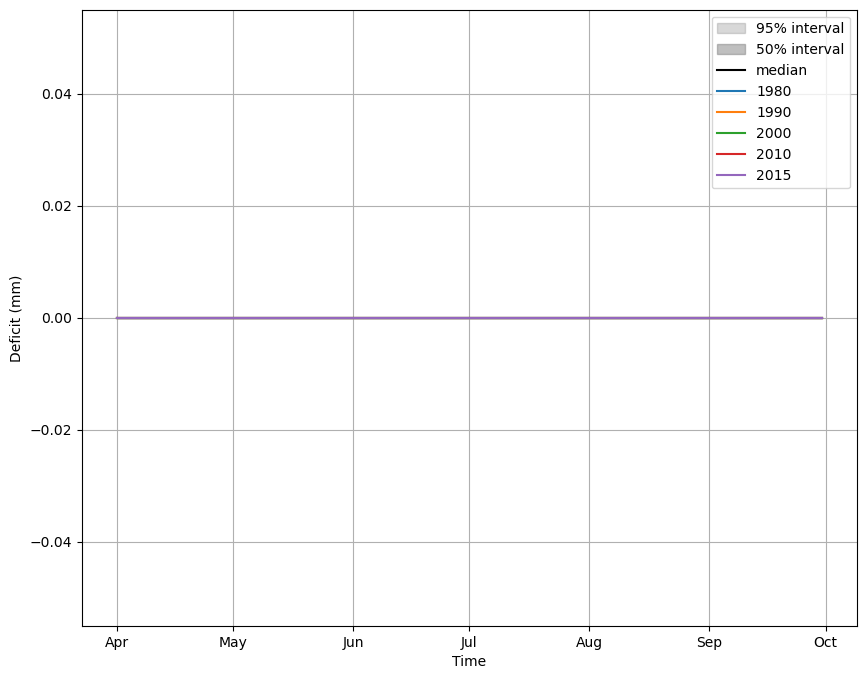

In [36]:
# plot the result
plot_pdef_year(rainfall_deficit_by_year, [1980, 1990, 2000, 2010, 2015])
plt.show()

In [37]:
def fit(ts, dist='gamma'):
    """
    This function fits a gamma distribution from a number of samples. It can be tested
    whether the process fits a Gamma distribution, because the function exports besides
    the fit parameters alpha and beta both the empirical plotting positions
    (x/(n+1)) and the plotting positions based on the fitted Gamma distribution.
    These can be used to construct goodness of fit or Q-Q plots
    Input:
        samples            : the samples from the process, to be described by
                             the Gamma distribution
    Output:
        alpha              : the shape parameter of the distribution
        loc                : the location (mean) parameter of the distribution
        beta               : the scale parameter of the distribution
        prob_zero          : the probability of zero-rainfall
        plot_pos_emp       : empirical plotting positions
        plot_pos_par       : parameterized plotting positions

    """

    samples = ts.values.flatten()  # flatten the matrix to a one-dimensional array
    # compute probability of zero rainfall
    prob_zero = float(sum(samples == 0)) / len(samples)
    # find the amount of samples
    n = len(samples)
    if dist == 'gamma':
        # select the gamma distribution function to work with
        dist_func = stats.gamma
    elif dist == 'gev':
        # select the generalized extreme value distribution function to work with
        dist_func = stats.genextreme
    # fit parameters of chosen distribution function, only through non-zero samples
    fit_params = dist_func.fit(samples[(samples != 0) & np.isfinite(samples)])
    # following is returned from the function
    return fit_params, prob_zero

def quantile_trans(ts, fit_params, p_zero, dist='gamma'):
    """
    This function detrermines the normal quantile transform of a number of samples, based on
    a known Gamma distribution of the precipitation process (can in principle
    be extended to support grids instead of point values)
    Input:
        samples            : the samples from the process, for which SPI is
                             computed
        alpha              : the shape parameter of the distribution
        loc                : the location (mean) parameter of the distribution
        beta               : the scale parameter of the distribution
        prob_zero          : the probability of zero-rainfall
    Output:
        SPI                : SPI values of the given samples
    """
    # compute probability of underspending of given sample(s), given the predefined Gamma distribution
    samples = ts.values
    # find zero samples
    ii = samples == 0
    # find missings in samples
    jj = np.isnan(samples)
    if dist == 'gamma':
        # select the gamma distribution function to work with
        dist_func = stats.gamma
    elif dist == 'gev':
        # select the gev distribution function to work with
        dist_func = stats.genextreme
    # compute the cumulative distribution function quantile values using the fitted parameters
    cdf_samples = dist_func.cdf(samples, *fit_params)
    # correct for no rainfall probability
    cdf_samples = p_zero + (1 - p_zero) * cdf_samples
    cdf_samples[ii] = p_zero
    cdf_samples[jj] = np.nan
    # compute inverse normal distribution with mu=0 and sigma=1, this yields the SPI value. 
    # Basically this means looking up how many standard deviations the given quantile represents in 
    # a normal distribution with mu=0. and sigma=1.
    SPI = stats.norm.ppf(cdf_samples)
    return SPI

def fit_and_transform(samples, dist='gamma'):
    # The function below fits the samples to the requested distribution 'gamma' or 'gev'
    fit_params, p_zero = fit(samples, dist=dist)
    # Then the fitted parameters are used to estimate the SPI for each invidual month
    spi_samples = quantile_trans(samples, fit_params, p_zero, dist=dist)
    # finally, the spi samples are put into a pandas timeseries again, so that we can easily make time series plots
    # and do further analyses
    return pd.Series(spi_samples, index=samples.index)

def compute_standard_index(ts, index='time.month', dist='gamma'):
    """
    Compute standardised index (e.g. SPI, SPEI). This is done on monthly time series by:
    - grouping the monthly data into monthly bins
    - for each month fit a distribution function (gamma or gev)
    - estimate the probability of exceedance of each point in the time series using the 12 distributions
    - estimate the normal transform of each probability found using mapping to a standard normal distribution
    Input:
        ts: pandas Series object containing monthly data (e.g. monthly precipitation, precip-ref. evaporation)
        index='time.month': index to use for grouping
        dist='gamma': distribution to use. Currently implemented are 'gamma' (default) and 'gev'.
    """
    # first, we group all values per month. So we get a group of January rainfalls, February rainfalls, etc.
    ts_group = ts.groupby(index)
    # for each group, the SPI values are computed and coerced into a new time series. 
    spi = ts_group.apply(fit_and_transform, dist=dist)
    spi = spi.sort_index(level=1)
    return spi

In [38]:
# select precipitation only, we don't need anything else.
P = np.maximum(station['precipitation'], 0.)/10 # converted to mm/day
# take monthly sums (a.k.a. monthlies)
P_month = P.resample('M').sum()  
# rename the data
P_month = P_month.rename('P_month')
# add to a larger dataframe
MonthFrame = pd.DataFrame(P_month)
MonthFrame.head()

C:\Users\mayal\AppData\Local\Temp\ipykernel_4208\910944599.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  P_month = P.resample('M').sum()


,P_month
time,
1979-01-31,0.007
1979-02-28,0.019
1979-03-31,3.461
1979-04-30,6.799
1979-05-31,15.306


In [39]:
# compute the spi using our nice function.
spi = compute_standard_index(P_month, index=P_month.index.month)
# add to our larger dataframe and rename
MonthFrame['SPI-01'] = spi.values
# observe the result in a table for the last five years
MonthFrame[-60:]

,P_month,SPI-01
time,,
2012-11-30,3.391,1.679505
2012-12-31,0.108,0.494151
2013-01-31,0.000,-0.096559
2013-02-28,2.408,1.401848
2013-03-31,4.732,1.018242
2013-04-30,5.141,-1.083042
2013-05-31,11.174,0.055153
2013-06-30,5.140,-1.910546
2013-07-31,11.145,-0.807777


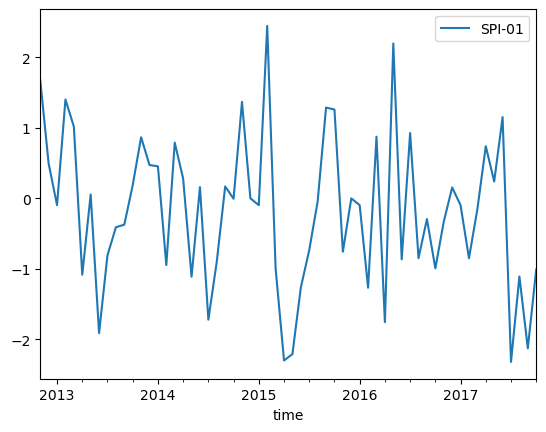

In [40]:
# plot the last 5 year values of spi
plt.figure()
MonthFrame['SPI-01'][-60:].plot()
# add a legend
plt.legend()
plt.show()

In [41]:
# compute 3-monthly SPI with the same function. We only need to first accumulate our data to 3-monthly values.
P_3month_rolling = P_month.rolling(3).sum()
print(P_3month_rolling)

time
1979-01-31       NaN
1979-02-28       NaN
1979-03-31     3.487
1979-04-30    10.279
1979-05-31    25.566
               ...  
2017-06-30    37.700
2017-07-31    33.726
2017-08-31    34.420
2017-09-30    25.936
2017-10-31    25.884
Freq: ME, Name: P_month, Length: 466, dtype: float64


In [42]:
# ... calculate the spi_03
spi_3 = compute_standard_index(P_3month_rolling, index=P_3month_rolling.index.month)
# ... add this again to our larger dataframe and observe the output for the last five years
MonthFrame['SPI-03'] = spi_3.values
MonthFrame[-60:]

,P_month,SPI-01,SPI-03
time,,,
2012-11-30,3.391,1.679505,1.763792
2012-12-31,0.108,0.494151,1.230736
2013-01-31,0.000,-0.096559,1.499958
2013-02-28,2.408,1.401848,1.133742
2013-03-31,4.732,1.018242,1.311359
2013-04-30,5.141,-1.083042,0.395798
2013-05-31,11.174,0.055153,-0.169782
2013-06-30,5.140,-1.910546,-1.544883
2013-07-31,11.145,-0.807777,-1.653318


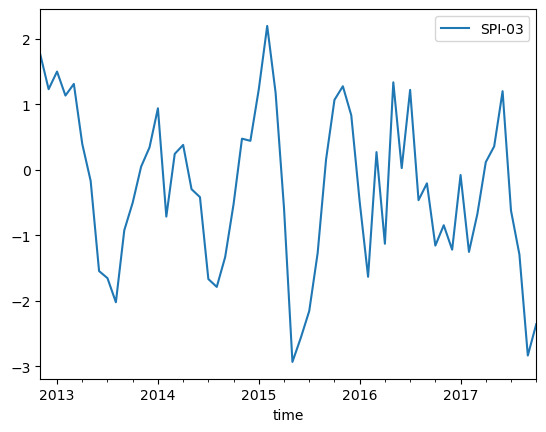

In [43]:
# ... again plot the last 5 years and add a legend
plt.figure()
MonthFrame['SPI-03'][-60:].plot()
# add a legend
plt.legend()
plt.show()

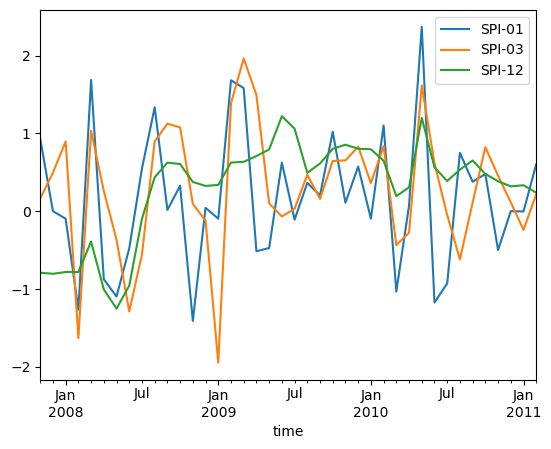

In [44]:
# ... compute 12 monthly SPI and do the plotting
P_12month_rolling = P_month.rolling(12).sum()
spi_12 = compute_standard_index(P_12month_rolling, index=P_month.index.month)
MonthFrame['P_12m'] = P_12month_rolling
MonthFrame['SPI-12'] = spi_12.values
MonthFrame[-60:]
# ... again plot the last 5 years and add a legend
MonthFrame[['SPI-01','SPI-03','SPI-12']][-120:-80].plot()
plt.legend()
plt.show()

In [45]:
def spells(df, wet_threshold = 1):
        '''This function calculates the dry spells for a growing season. A dry spell is indexed on its last day.
        Note: This function does not support a growing season spanning different calendar years.
        
        :: Inputs ::
        df = dataframe containing just growing season information, assuming daily data
        wet_threshold: Minimum precipitation for what constitutes a wet day in mm/day.
        
        :: Outputs :: 
        ds: DataFrame with dry spells
        '''
        
        df['DRY'] = (df['P_mm_day'] < wet_threshold) # Adding a column checking for dry and wet days. dry == True, wet == False
        Years = np.unique(df.index.year)
        spells_stored = []
        spell_end_dates = []
        for j in np.arange(len(Years)):
            df_year = df.loc[str(Years[j])]
            spell_length_counter = 0
            i = 0 # day counter
            while i < len(df_year):
                dry_day = df_year['DRY'].iloc[i]
                if dry_day == True: # increase the counter
                    spell_length_counter += 1
                else: # dry_day == False; Report a dry spell the moment that a wet day arrives:
                    if spell_length_counter != 0:
                        spells_stored += [spell_length_counter] # store previous spell in new list
                        spell_end_dates += [df_year.index[i-1]] # store associated end date in new list
                        spell_length_counter = 0 # reset spell_length_counter
                i += 1
 
        ds = pd.DataFrame(data = spells_stored, index = spell_end_dates)
        ds.columns = ['Dry Spell Length']
        return ds

In [46]:
# remember that we have already have a dataframe (from exercise 2.1) with the daily values of several variables including daily precipitation
station_growing_season.head(10)

,precipitation,Epot_mm_day,P_mm_day,Epot-P
time,,,,
1979-04-01,0.88,0.0,0.088,-0.088
1979-04-02,0.83,0.0,0.083,-0.083
1979-04-03,0.00,0.0,0.000,0.000
1979-04-04,0.00,0.0,0.000,0.000
1979-04-05,0.00,0.0,0.000,0.000
1979-04-06,0.00,0.0,0.000,0.000
1979-04-07,0.20,0.0,0.020,-0.020
1979-04-08,0.00,0.0,0.000,0.000
1979-04-09,0.02,0.0,0.002,-0.002


In [47]:
# let's take out just precipitation and convert it to a separate dataframe
P_mm_day = station_growing_season['P_mm_day']
SimpleStation = pd.DataFrame(P_mm_day)
SimpleStation.head()
# We can then call our function spells and store them in another variable again
# Note wet_threshold = 1, which means we set a minimum threshold of 1 mm/day for a wet day
DrySpells = spells(SimpleStation, wet_threshold = 1)

# have look at the data in general
DrySpells.tail(20)

,Dry Spell Length
2016-09-03,1
2016-09-07,2
2016-09-13,5
2016-09-22,8
2017-04-02,2
2017-04-24,21
2017-05-19,23
2017-05-30,10
2017-06-05,5
2017-06-15,9


In [48]:
# and have a look at the maximum dry spells
DrySpells.sort_values(by='Dry Spell Length',ascending=False).head(20)

,Dry Spell Length
1987-06-09,67
2015-05-23,53
1989-05-25,44
1984-05-16,37
1980-07-04,36
1993-06-22,35
1992-05-04,34
2017-07-31,33
2013-07-05,33
1986-05-03,33


In [49]:
# compute the variables above
values = DrySpells['Dry Spell Length'].value_counts().sort_index()
print(values)

d = np.array(values.index)
print('d = ' + str(d))

n_occ = np.array(values)
print('n_occ = ' + str(n_occ))

Dry Spell Length
1     122
2     152
3     113
4      83
5      76
6      54
7      52
8      41
9      30
10     20
11     24
12     20
13     21
14     17
15     13
16     12
17     11
18      2
19      3
20      4
21     10
22      6
23      2
24      1
25      2
26      2
28      2
29      1
30      1
31      1
32      2
33      3
34      1
35      1
36      1
37      1
44      1
53      1
67      1
Name: count, dtype: int64
d = [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 28 29 30 31 32 33 34 35 36 37 44 53 67]
n_occ = [122 152 113  83  76  54  52  41  30  20  24  20  21  17  13  12  11   2
   3   4  10   6   2   1   2   2   2   1   1   1   2   3   1   1   1   1
   1   1   1]


In [50]:
# ... continue computing the other variables

# spells>=d, n_ex i.e. the total number of equal to or exceedance
n_ex = np.zeros(len(d))
for i in range(len(n_ex)):
    n_ex[i] = np.sum(n_occ[i:])
print(n_ex)

# rate of exceedance, r (1/year)
y = len(np.unique(station_growing_season.index.year))
r = n_ex/y
print(r)

p = 1-np.exp(-r*1)
print(p)

[910. 788. 636. 523. 440. 364. 310. 258. 217. 187. 167. 143. 123. 102.
  85.  72.  60.  49.  47.  44.  40.  30.  24.  22.  21.  19.  17.  15.
  14.  13.  12.  10.   7.   6.   5.   4.   3.   2.   1.]
[23.33333333 20.20512821 16.30769231 13.41025641 11.28205128  9.33333333
  7.94871795  6.61538462  5.56410256  4.79487179  4.28205128  3.66666667
  3.15384615  2.61538462  2.17948718  1.84615385  1.53846154  1.25641026
  1.20512821  1.12820513  1.02564103  0.76923077  0.61538462  0.56410256
  0.53846154  0.48717949  0.43589744  0.38461538  0.35897436  0.33333333
  0.30769231  0.25641026  0.17948718  0.15384615  0.12820513  0.1025641
  0.07692308  0.05128205  0.02564103]
[1.         1.         0.99999992 0.9999985  0.9999874  0.99991157
 0.99964689 0.9986604  0.99616698 0.99172794 0.9861857  0.97443847
 0.95731237 0.92686035 0.88690048 0.84215691 0.78528883 0.7153259
 0.70034642 0.67638642 0.64143346 0.53663063 0.459567   0.43112956
 0.41635452 0.38564325 0.35331595 0.3192876  0.30160774 0.2

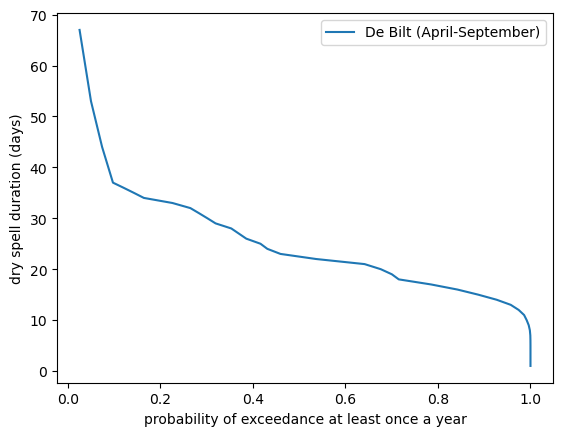

In [51]:
# ... plot the graph
plt.figure()
plt.plot(p,d, label = 'De Bilt (April-September)')
plt.xlabel('probability of exceedance at least once a year')
plt.ylabel('dry spell duration (days)')
plt.legend()
plt.show()

In [52]:
# Optionally run this code after computing all variables to put them in a nice table 
data = {'d': d, 'n_occ': n_occ, 'n_ex': np.int64(n_ex), 'r': r, 'p': p}
DryTable = pd.DataFrame.from_dict(data)
DryTable

,d,n_occ,n_ex,r,p
0,1,122,910,23.333333,1.000000
1,2,152,788,20.205128,1.000000
2,3,113,636,16.307692,1.000000
3,4,83,523,13.410256,0.999999
4,5,76,440,11.282051,0.999987
5,6,54,364,9.333333,0.999912
6,7,52,310,7.948718,0.999647
7,8,41,258,6.615385,0.998660
8,9,30,217,5.564103,0.996167
9,10,20,187,4.794872,0.991728
